# SI figures

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
import random_growth_src.lib as lib
import matplotlib.colors as colors
import matplotlib.cm as cm

plt.style.use("../project_style.mplstyle")
%config InlineBackend.figure_format = 'retina'

## Growth rate in the mean field limit with coloured noise

### Numerical results

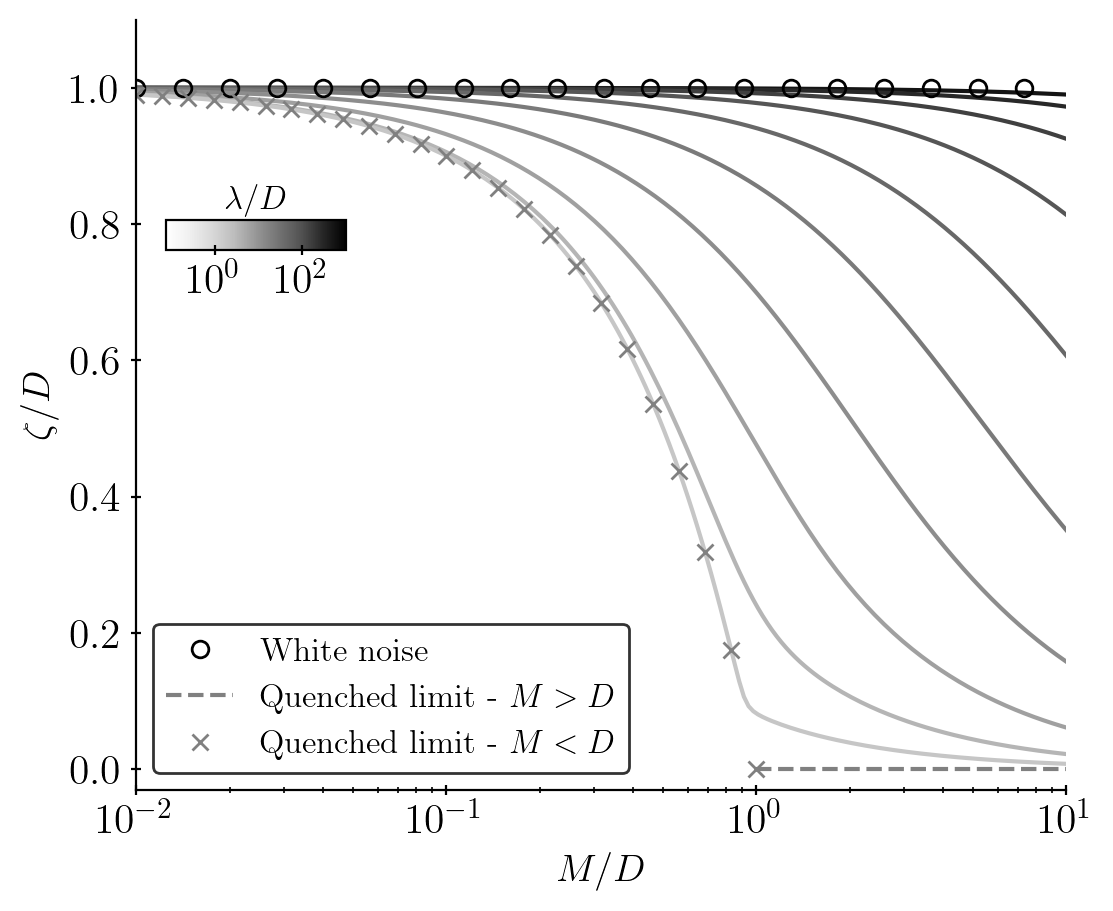

In [77]:
fig, ax = plt.subplots(figsize=(6, 5))

lambda_tildes = np.logspace(3, -1.1, 10)
M_tildes = np.logspace(-2, 1, 200)
palette = sns.color_palette("Greys_r", len(lambda_tildes) + 4)
color_iter = iter(palette)
for i, lambda_tilde in enumerate(lambda_tildes): 
    c = next(color_iter )
    growth_rates_color = []
    for M_tilde in M_tildes:
        growth_rates_color.append(lib.solve_zeta(M_tilde, 1, lambda_tilde))
    ax.plot(M_tildes, growth_rates_color, color=c)
    
ax.plot(M_tildes, np.ones(len(M_tildes)), label='White noise', linestyle="None", marker="o", markevery=10, markerfacecolor='none', c='black')
ax.plot(np.logspace(0, 1, 100), 0.0 * np.logspace(0, 1, 100), linestyle="--", c='grey', label=r'Quenched limit - ${M > D}$')
ax.plot(np.logspace(-2, 0, 25), 1 - np.logspace(-2, 0, 25), linestyle="None", marker="x", c='grey', label=r'Quenched limit - ${M < D}$')
cbar_ax = fig.add_axes([0.15, 0.65, 0.15, 0.03]) 
sm = cm.ScalarMappable(cmap=sns.color_palette("Greys", as_cmap=True), norm=colors.LogNorm(vmin=lambda_tildes.min(), vmax=lambda_tildes.max())) 
cbar = plt.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label(r"$\lambda / D$", fontsize=12)
cbar.ax.xaxis.set_label_position("top")
ax.set_xscale('log')
ax.set_xlabel(r'$M / D$')
ax.set_ylabel(r'$\zeta / D$')
ax.set_ylim([-0.03, 1.1])
ax.set_xlim([1e-2, 1e1])
ax.legend(edgecolor='black')
plt.savefig('../figures/SI_optimal_growth_mean_field.pdf', bbox_inches='tight', dpi=200, transparent=True);

## Scaling for $N=2$ versus $N \rightarrow \infty$ - white noise

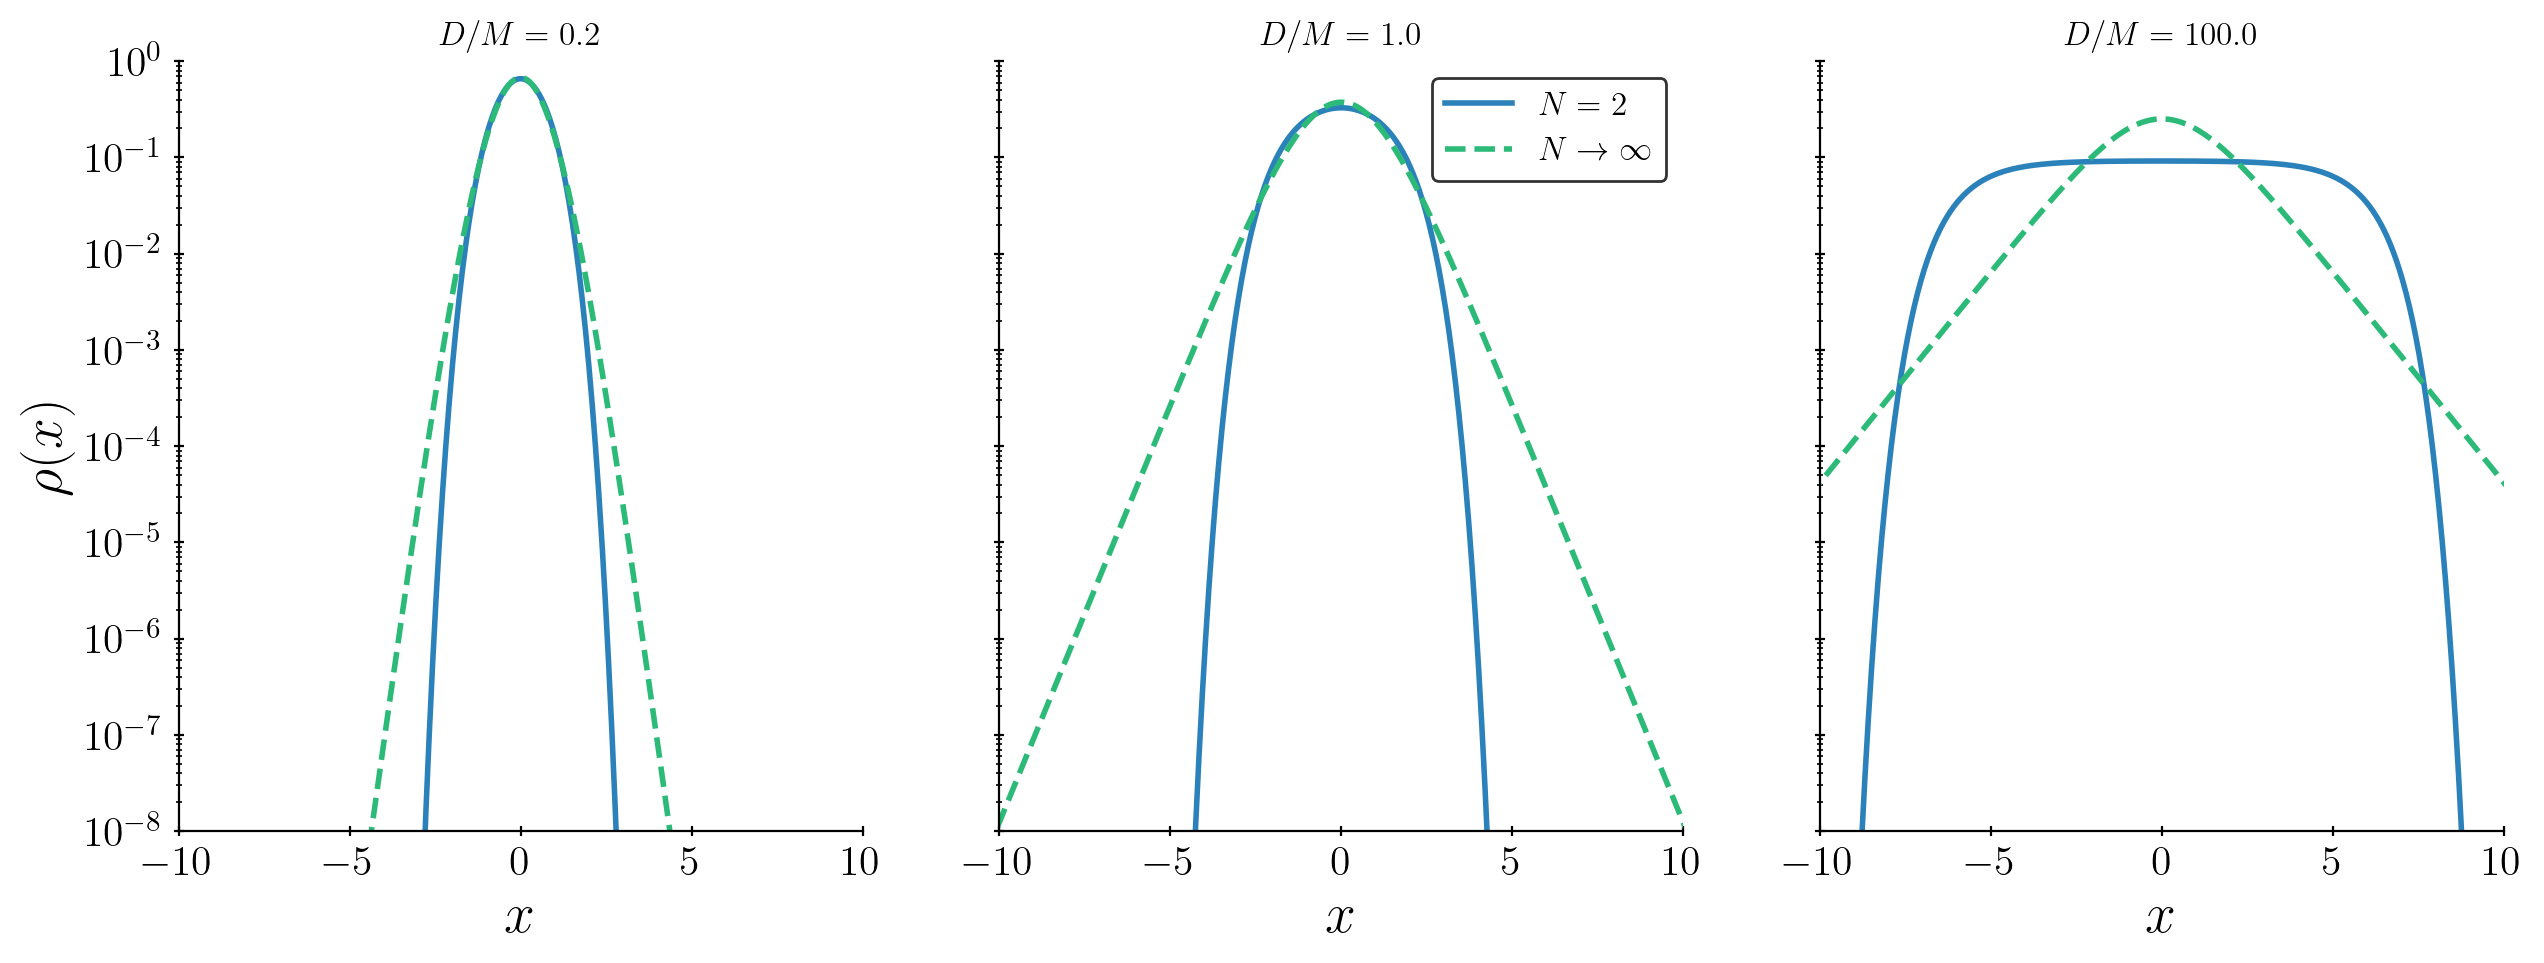

In [35]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)

x_vals = np.linspace(-12, 12, 500)

ratios = [5, 1, 0.01]
for i, ratio in enumerate(ratios):
    ax[i].plot(x_vals, lib.two_patch_steady_state_density_x_white_noise(x_vals, ratio, 1), linewidth=2, alpha=1, label=r'$N =2$', c='#2B82BA')
    ax[i].plot(x_vals, lib.mean_field_steady_state_density_x_white_noise(x_vals, ratio, 1), linewidth=2, alpha=1, label=r'$N \rightarrow \infty$', c="#2BBA77", linestyle='--')
    ax[i].set_title(rf"$D / M = {1/ratio}$")
    ax[i].set_xlabel("$x$", fontsize=20)
    
    
ax[0].set_yscale('log')
ax[0].set_ylim([1e-8, 1e0])
ax[0].set_xlim([-10, 10])
ax[0].set_ylabel(r"$\rho(x)$", fontsize=20)
ax[1].legend(edgecolor='black')
plt.savefig('../figures/SI_tail_scaling.pdf', bbox_inches='tight', dpi=200, transparent=True);

## Analytics vs simulations

### White noise 

#### $N=2$

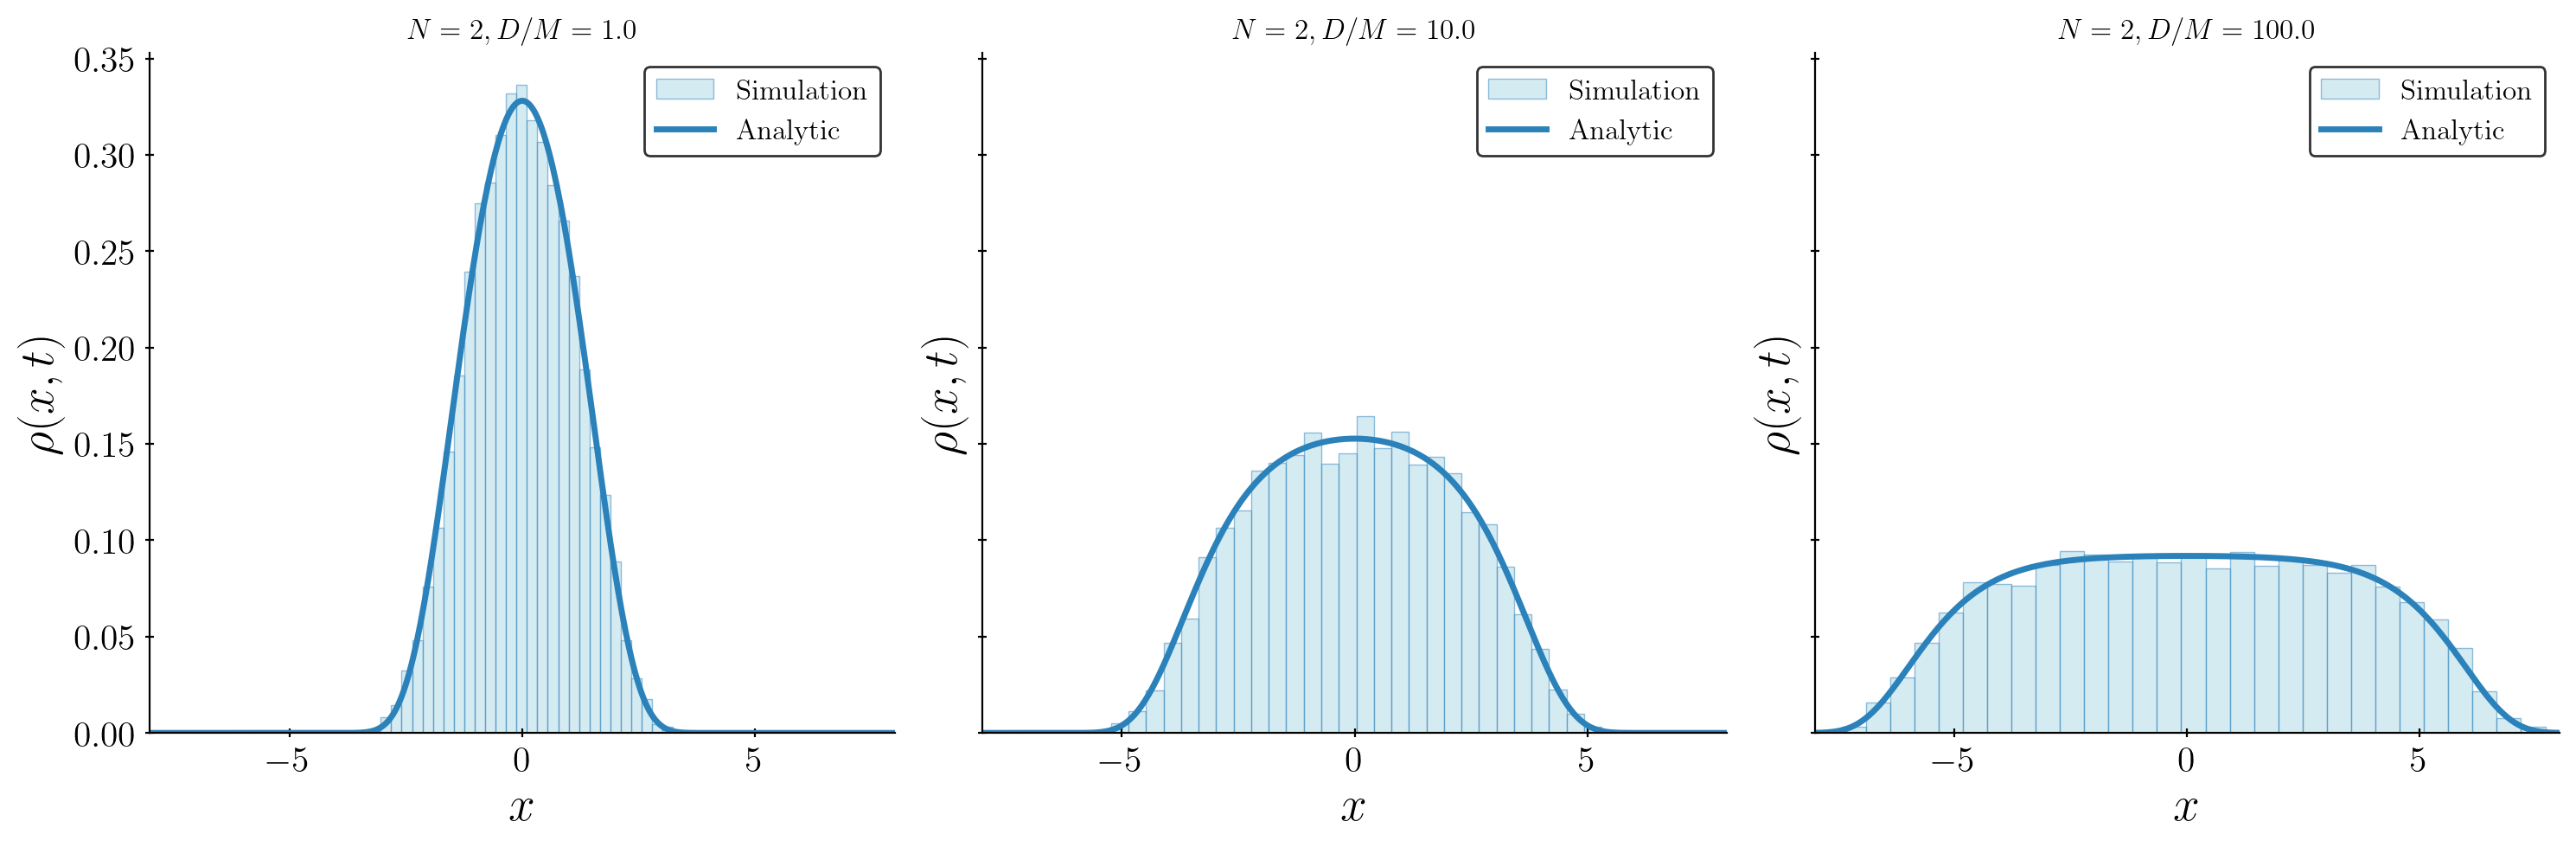

In [ ]:
n_steps = int(2e4)
n_runs = int(1e4)
t_max = 500
dt = t_max/n_steps

fig, ax = plt.subplots(1, 3, figsize=(15, 5), layout='tight', sharex=True, sharey=True)

t_eval = 400
x_vals = np.linspace(-10, 10, 500)

x0 = np.full(n_runs, 0.0)
D = 1
Ms = [1, 0.1, 0.01]
for i, M in enumerate(Ms):
    sim_step = partial(lib.two_patch_x_white_noise_step, M=M, D=D)
    results_x_two_patch, results_t_two_patch = lib.run_simulation(x0, t_max, n_runs, n_steps, sim_step)

    ax[i].hist(results_x_two_patch[np.argmin(np.abs(results_t_two_patch - t_eval))], bins=30, density=True, color='lightblue', linewidth=0.5, edgecolor='#2B82BA', alpha=0.5, label='Simulation')
    ax[i].plot(x_vals, lib.two_patch_steady_state_density_x_white_noise(x_vals, M, D), linewidth=2.5, c='#2B82BA', alpha=1, label='Analytic')

    ax[i].set_xlim([np.min(results_x_two_patch), np.max(results_x_two_patch)])
    ax[i].set_xlabel("$x$", fontsize=20)
    ax[i].set_ylabel("$\\rho(x, t)$", fontsize=20)
    ax[i].set_title(fr"$N=2, D/M={D/M}$")
    ax[i].legend(edgecolor='black')

ax[0].set_xlim([-8, 8])
plt.savefig('../figures/SI_numerics_vs_sim_white_noise_two_patch.pdf', bbox_inches='tight', dpi=200, transparent=True);

#### $N \rightarrow \infty$

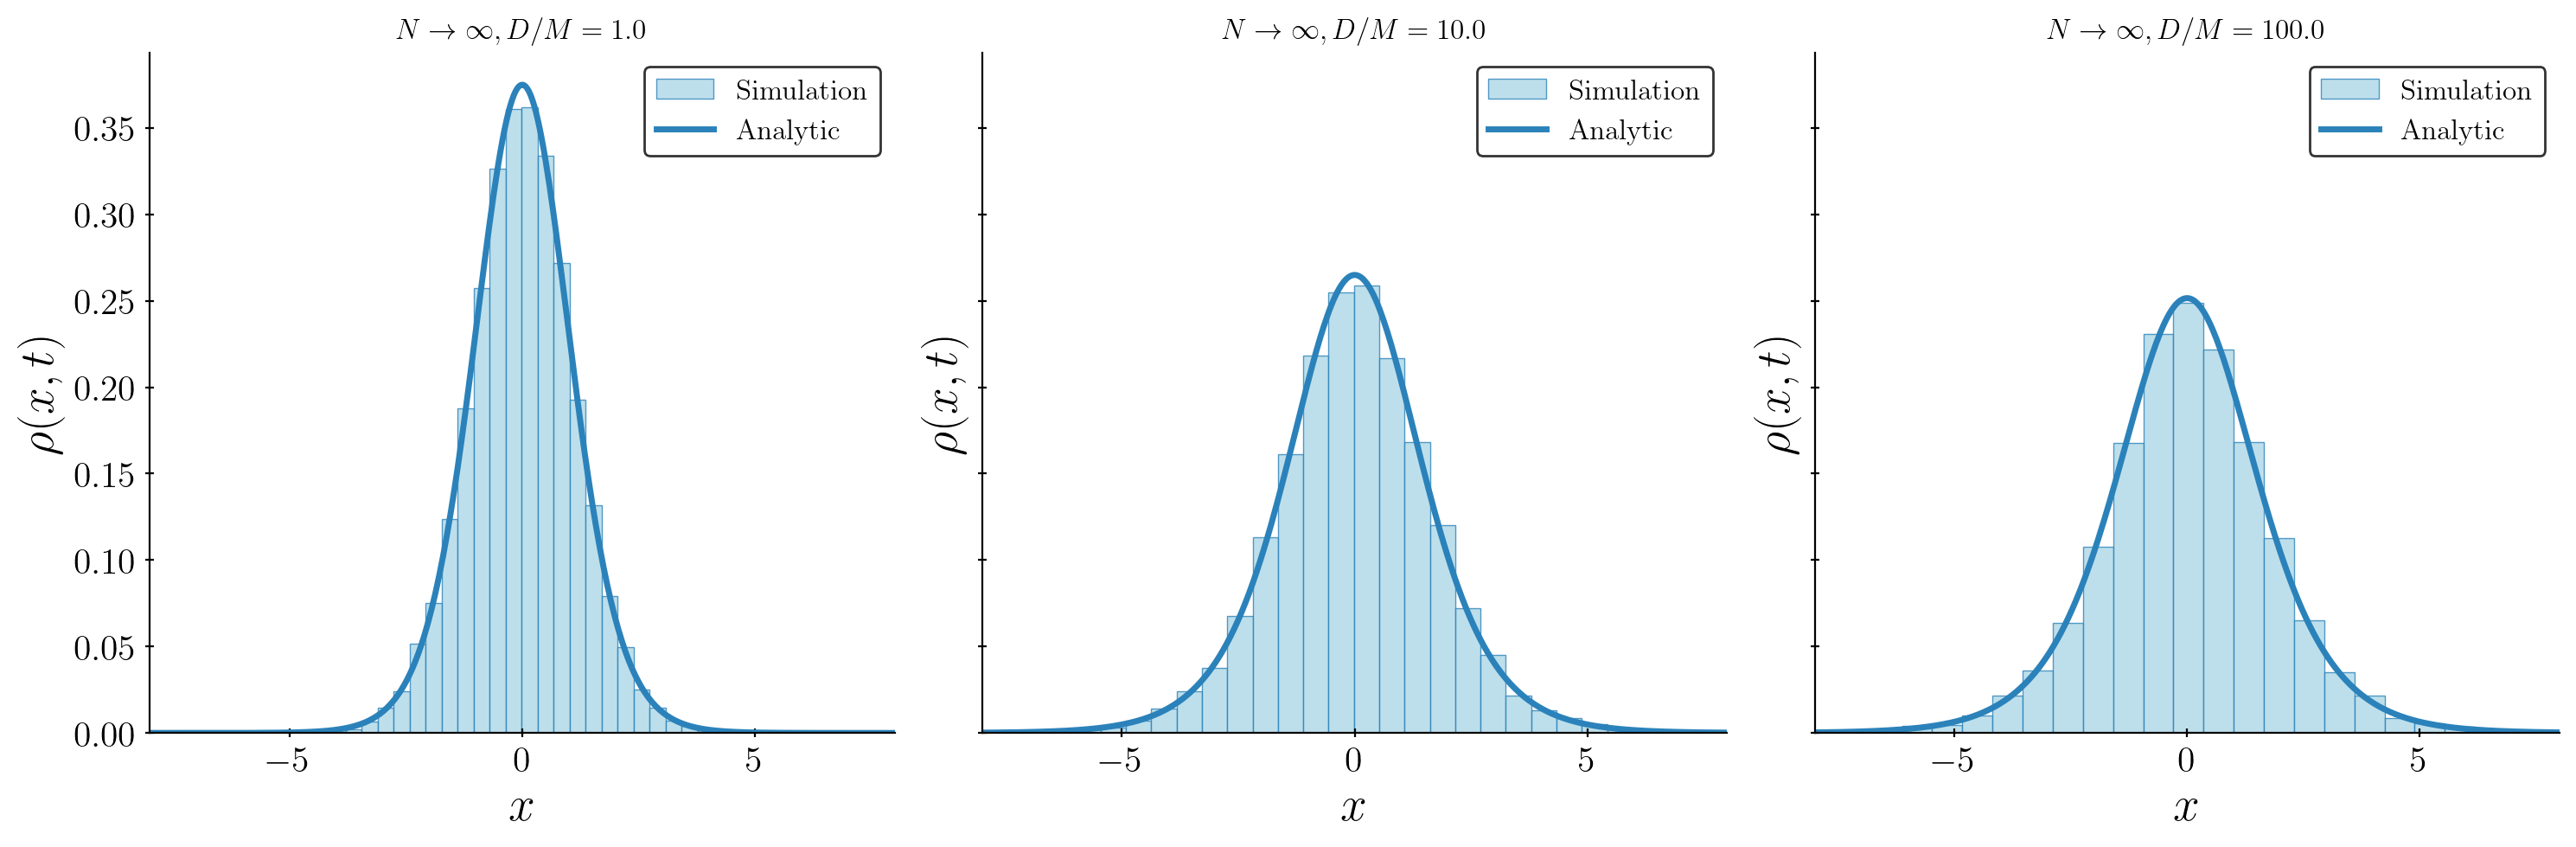

In [ ]:
n_steps = int(2e4)
n_runs = int(1e4)
t_max = 500
dt = t_max/n_steps

fig, ax = plt.subplots(1, 3, figsize=(15, 5), layout='tight', sharex=True, sharey=True)

t_eval = 400
x_vals = np.linspace(-10, 10, 500)

y0 = np.full(n_runs, 0.0)
D = 1
Ms = [1, 0.1, 0.01]
for i, M in enumerate(Ms):
    sim_step = partial(lib.mean_field_y_white_noise_step, M=M, D=D)
    results_y1, results_t = lib.run_simulation(y0, t_max, n_runs, n_steps, sim_step)
    results_y2, results_t = lib.run_simulation(y0, t_max, n_runs, n_steps, sim_step)
    results_x_mf = results_y1 - results_y2

    ax[i].hist(results_x_mf[np.argmin(np.abs(results_t - t_eval))], bins=30, density=True, color='lightblue', linewidth=0.5, edgecolor='#2B82BA', alpha=0.8, label='Simulation')
    ax[i].plot(x_vals, lib.mean_field_steady_state_density_x_white_noise(x_vals, M, D), linewidth=2.5, c='#2B82BA', alpha=1, label='Analytic')

    ax[i].set_xlim([-10, 10])
    ax[i].set_xlabel("$x$", fontsize=20)
    ax[i].set_ylabel("$\\rho(x, t)$", fontsize=20)
    ax[i].set_title(fr"$N\rightarrow \infty, D/M={D/M}$")
    ax[i].legend(edgecolor='black')
    
ax[0].set_xlim([-8, 8])  
plt.savefig('../figures/SI_numerics_vs_sim_white_noise_mf.pdf', bbox_inches='tight', dpi=200, transparent=True);

### Coloured noise 

#### $N=2$

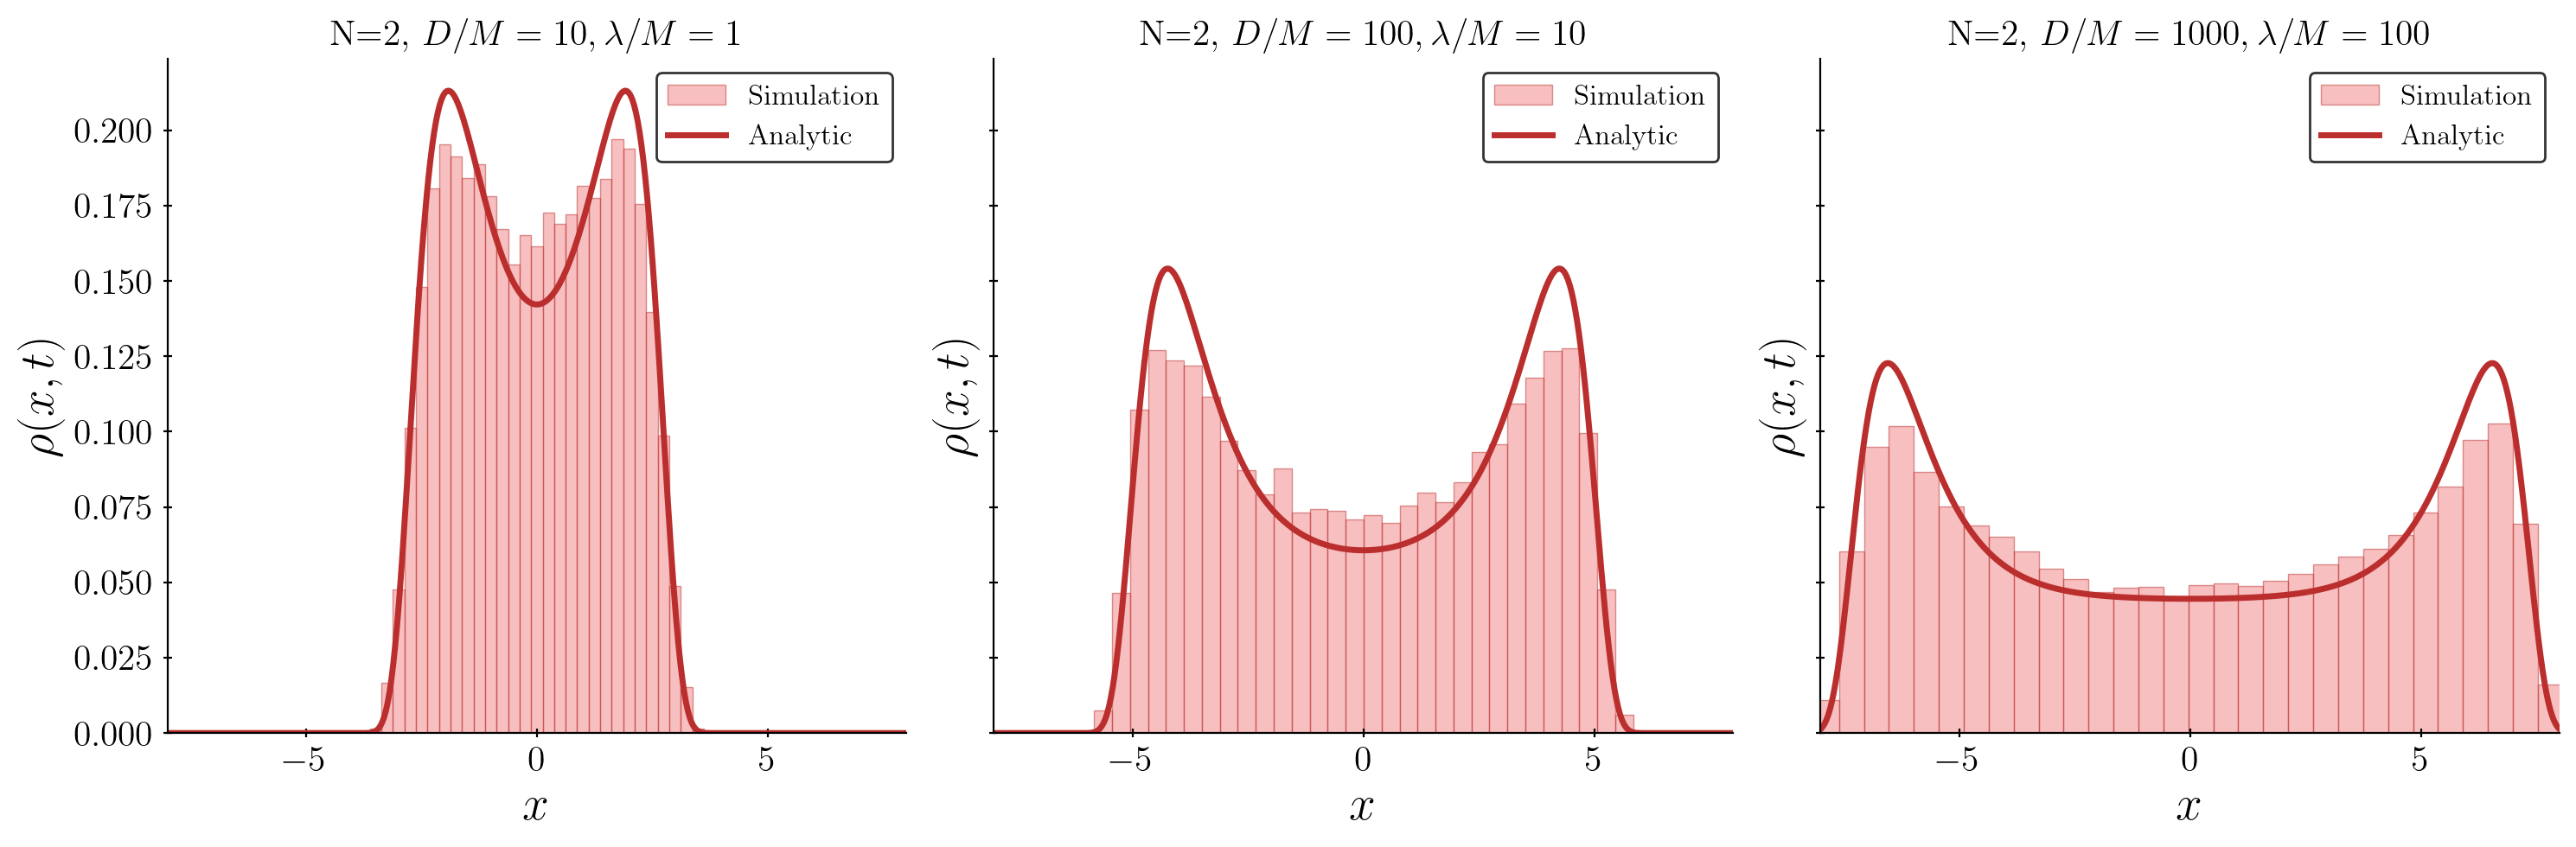

In [ ]:
n_steps = int(2e4)
n_runs = int(2e4)
t_max = 500
dt = t_max/n_steps

fig, ax = plt.subplots(1, 3, figsize=(15, 5), layout='tight', sharex=True, sharey=True)

t_eval = 400
x_vals = np.linspace(-10, 10, 500)

x0 = np.full(n_runs, np.log10(1))
eta0 = np.full(n_runs, 0.0)
lamb = 1
D = 10
Ms = [1, 0.1, 0.01]
for i, M in enumerate(Ms):
    sim_step = partial(lib.two_patch_x_coloured_noise_step, M=M, D=D, lamb=lamb)
    results_x_coloured_two_patch, results_t = lib.run_simulation(x0, t_max, n_runs, n_steps, sim_step, eta0=eta0)
    
    ax[i].hist(results_x_coloured_two_patch[np.argmin(np.abs(results_t - t_eval))], bins=30, density=True, color='lightcoral', linewidth=0.5, edgecolor="#BB2E2E", alpha=0.5, label='Simulation')
    ax[i].plot(x_vals, lib.two_patch_steady_state_density_x_coloured_noise(x_vals, M, D, lamb), linewidth=2.5, c="#BB2E2E", alpha=1, linestyle="-", label='Analytic')

    ax[i].set_xlim([np.min(results_x_coloured_two_patch), np.max(results_x_coloured_two_patch)])
    ax[i].set_xlabel("$x$", fontsize=20)
    ax[i].set_ylabel("$\\rho(x, t)$", fontsize=20)
    ax[i].set_title(rf"N=2, $D/M = {D/M:.0f}, \lambda/M = {lamb/M:.0f}$", fontsize=15)
    ax[i].legend(edgecolor='black');
  
ax[0].set_xlim([-8, 8])  
plt.savefig('../figures/SI_numerics_vs_sim_coloured_noise_two_patch.pdf', bbox_inches='tight', dpi=200, transparent=True);

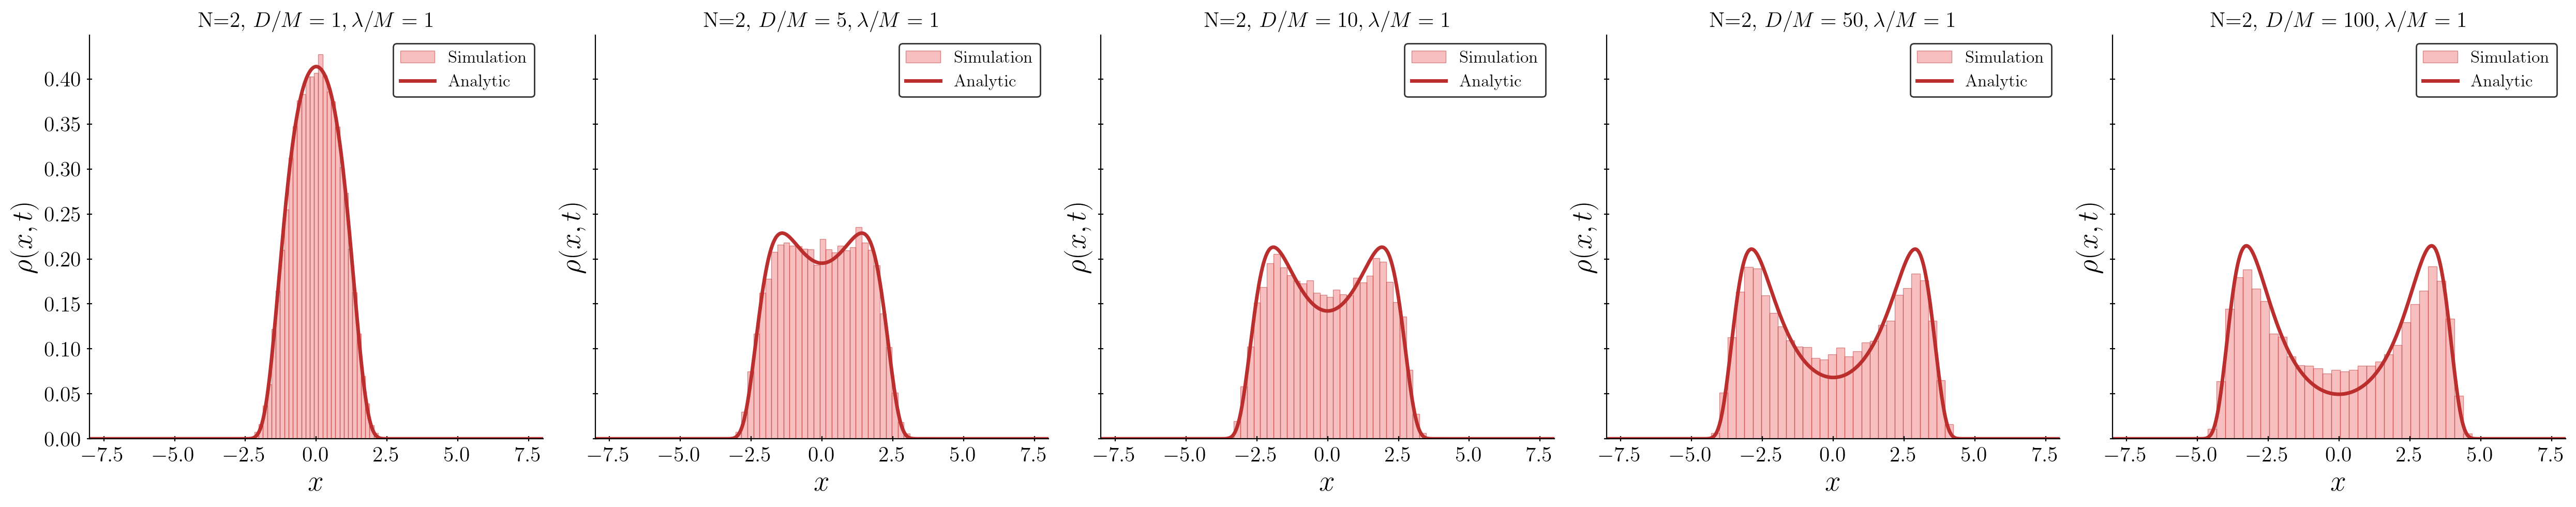

In [81]:
n_steps = int(2e4)
n_runs = int(2e4)
t_max = 500
dt = t_max/n_steps

fig, ax = plt.subplots(1, 5, figsize=(25, 5), layout='tight', sharex=True, sharey=True)

t_eval = 400
x_vals = np.linspace(-10, 10, 500)

x0 = np.full(n_runs, np.log10(1))
eta0 = np.full(n_runs, 0.0)
lamb = 1
Ds = [1, 5, 10, 50, 100]
M = 1
for i, D in enumerate(Ds):
    sim_step = partial(lib.two_patch_x_coloured_noise_step, M=M, D=D, lamb=lamb)
    results_x_coloured_two_patch, results_t = lib.run_simulation(x0, t_max, n_runs, n_steps, sim_step, eta0=eta0)
    
    ax[i].hist(results_x_coloured_two_patch[np.argmin(np.abs(results_t - t_eval))], bins=30, density=True, color='lightcoral', linewidth=0.5, edgecolor="#BB2E2E", alpha=0.5, label='Simulation')
    
    ax[i].plot(x_vals, lib.two_patch_steady_state_density_x_coloured_noise(x_vals, M, D, lamb), linewidth=2.5, c="#BB2E2E", alpha=1, linestyle="-", label='Analytic')

    ax[i].set_xlim([np.min(results_x_coloured_two_patch), np.max(results_x_coloured_two_patch)])
    ax[i].set_xlabel("$x$", fontsize=20)
    ax[i].set_ylabel("$\\rho(x, t)$", fontsize=20)
    ax[i].set_title(rf"N=2, $D/M = {D/M:.0f}, \lambda/M = {lamb/M:.0f}$", fontsize=15)
    ax[i].legend(edgecolor='black');
    
ax[0].set_xlim([-8, 8])  
plt.savefig('../figures/SI_numerics_vs_sim_coloured_noise_two_patch_slice_in_D.pdf', bbox_inches='tight', dpi=200, transparent=True);

In [ ]:
n_steps = int(3e4)
n_runs = int(3e4)
t_max = 500
dt = t_max/n_steps

fig, ax = plt.subplots(1, 5, figsize=(25, 5), layout='tight', sharex=True, sharey=True)

t_eval = 400
x_vals = np.linspace(-15, 15, 500)

x0 = np.full(n_runs, np.log10(1))
eta0 = np.full(n_runs, 0.0)
lambs = [0.05, 0.1, 1, 10, 20]
Ds = 10
M = 1
for i, lamb in enumerate(lambs):
    sim_step = partial(lib.two_patch_x_coloured_noise_step, M=M, D=D, lamb=lamb)
    results_x_coloured_two_patch, results_t = lib.run_simulation(x0, t_max, n_runs, n_steps, sim_step, eta0=eta0)
    
    ax[i].hist(results_x_coloured_two_patch[np.argmin(np.abs(results_t - t_eval))], bins=30, density=True, color='lightcoral', linewidth=0.5, edgecolor="#BB2E2E", alpha=0.5, label='Simulation')
    ax[i].plot(x_vals, lib.two_patch_steady_state_density_x_coloured_noise(x_vals, M, D, lamb), linewidth=2.5, c="#BB2E2E", alpha=1, linestyle="-", label='Analytic')
    
    ax[i].set_xlabel("$x$", fontsize=20)
    ax[i].set_ylabel("$\\rho(x, t)$", fontsize=20)
    ax[i].set_title(rf"N=2, $D/M = {D/M:.0f}, \lambda/M = {lamb/M:.0e}$", fontsize=15)
    ax[i].legend(edgecolor='black');
  
ax[0].set_xlim([-8, 8]) 
plt.savefig('../figures/SI_numerics_vs_sim_coloured_noise_two_patch_slice_in_lambda.pdf', bbox_inches='tight', dpi=200, transparent=True);

/Users/james/Documents/Projects/Birth_death_immigration_2024/paper_random_growth_and_migration/code/random_growth_src/lib/simulations.py:23: RuntimeWarning: overflow encountered in sinh
  x = x + ((- M * np.sinh(x) + eta) * dt)
/Users/james/Documents/Projects/Birth_death_immigration_2024/paper_random_growth_and_migration/code/random_growth_src/lib/simulations.py:23: RuntimeWarning: invalid value encountered in add
  x = x + ((- M * np.sinh(x) + eta) * dt)


#### $N \rightarrow \infty$

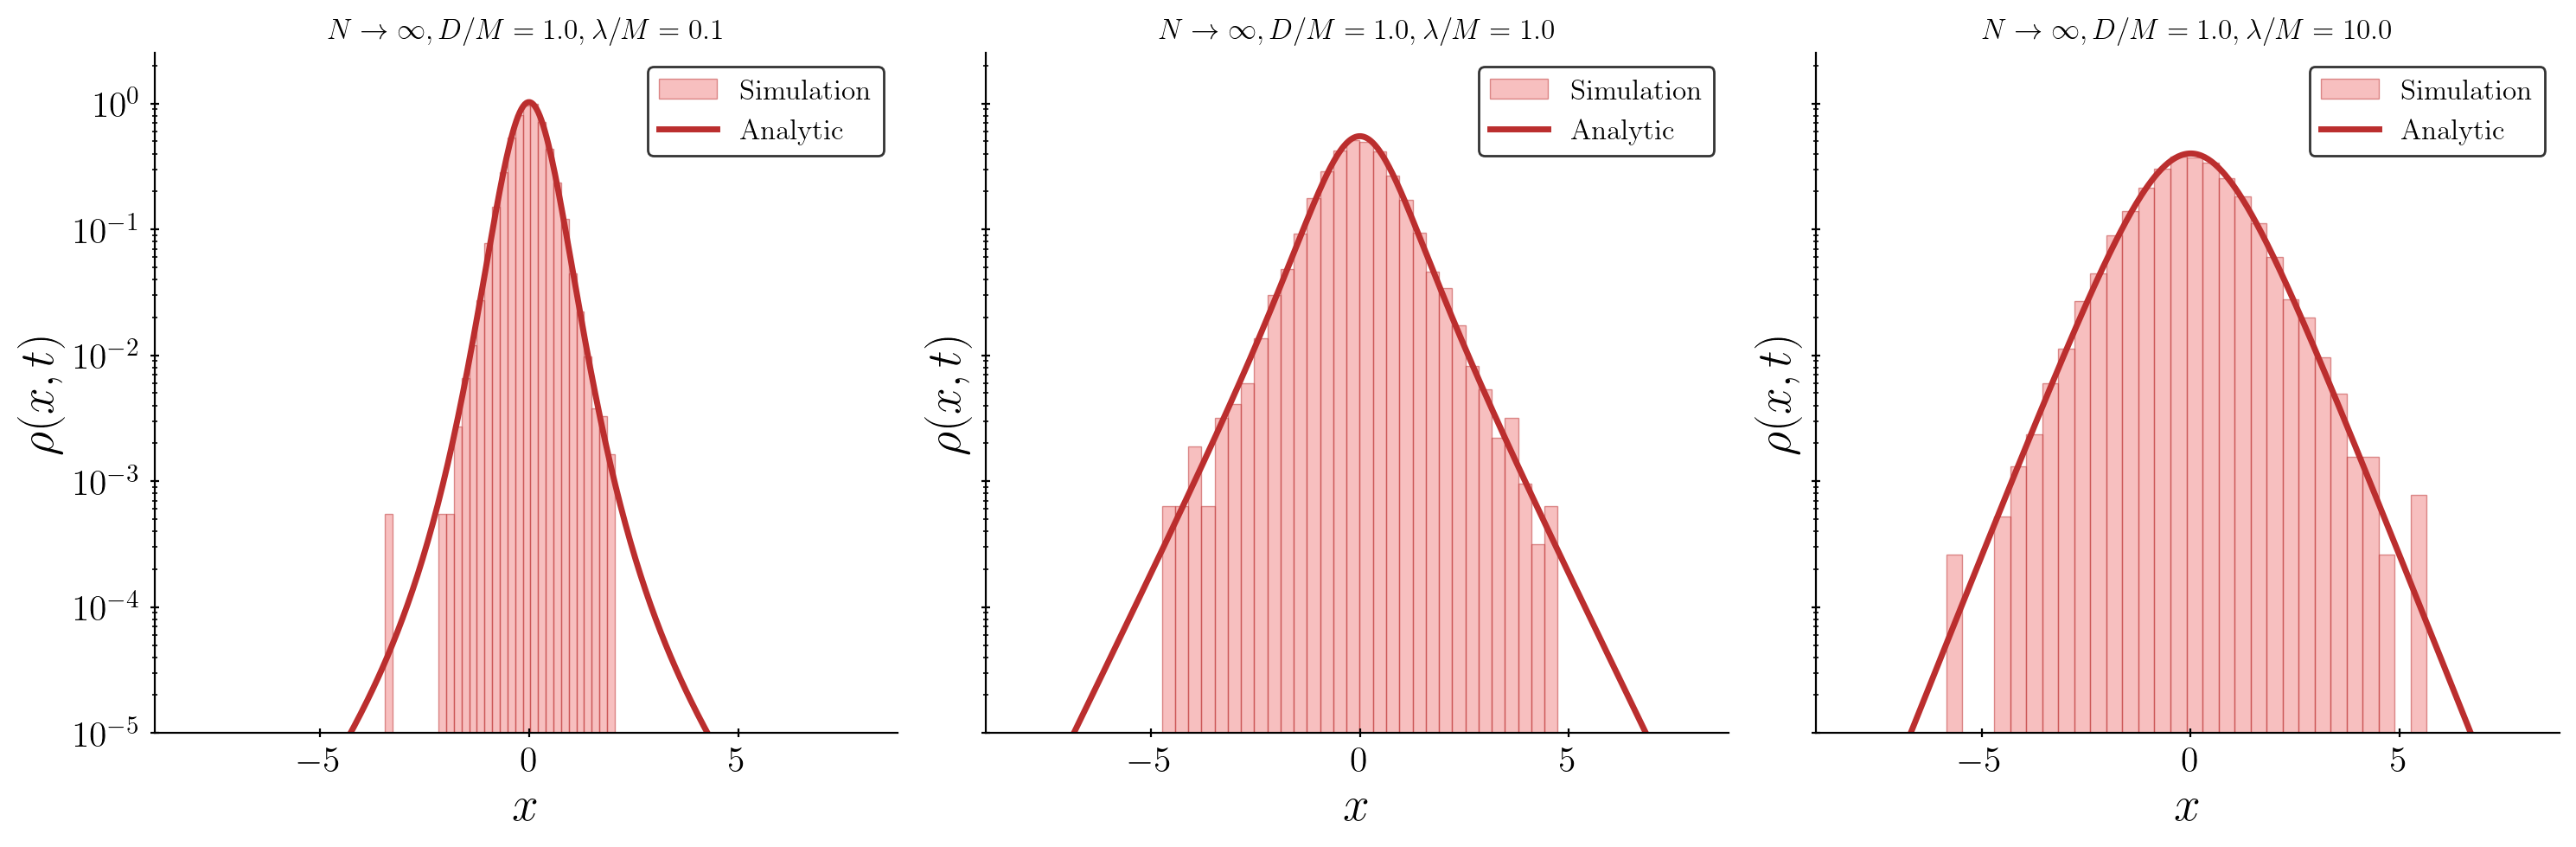

In [ ]:
n_steps = int(2e4)
n_runs = int(1e4)
t_max = 500
dt = t_max/n_steps

fig, ax = plt.subplots(1, 3, figsize=(15, 5), layout='tight', sharex=True, sharey=True)

t_eval = 400
x_vals = np.linspace(-10, 10, 500)

y0 = np.full(n_runs, 0.0)
eta0 = np.full(n_runs, 0.0)
M = 1
D = 1
lambs = [0.1, 1, 10]
for i, lamb in enumerate(lambs):
    
    sim_step = partial(lib.mean_field_y_coloured_noise_step, M=M, D=D, lamb=lamb)
    results_y1, results_t = lib.run_simulation(y0, t_max, n_runs, n_steps, sim_step, eta0=eta0)
    results_y2, results_t = lib.run_simulation(y0, t_max, n_runs, n_steps, sim_step, eta0=eta0)
    results_x_coloured_mf = results_y1 - results_y2
    
    ax[i].hist(results_x_coloured_mf[int(t_eval/dt)], bins=30, density=True, color='lightcoral', linewidth=0.5, edgecolor="#BB2E2E", alpha=0.5,  label='Simulation')
    ax[i].plot(x_vals, lib.mean_field_steady_state_density_x_coloured_noise(x_vals, M, D, lamb), linewidth=2.5, c="#BB2E2E", alpha=1, linestyle="-", label='Analytic')

    ax[i].set_xlim([np.min(results_x_coloured_mf), np.max(results_x_coloured_mf)])
    ax[i].set_xlabel("$x$", fontsize=20)
    ax[i].set_ylabel("$\\rho(x, t)$", fontsize=20)
    ax[i].set_title(fr"$N\rightarrow \infty, D/M={D/M},  \lambda/M={lamb/M}$")
    ax[i].set_yscale('log')
    ax[i].legend(edgecolor='black');
    
ax[0].set_ylim([1e-5, None])
plt.savefig('../figures/SI_numerics_vs_sim_coloured_noise_mf.pdf', bbox_inches='tight', dpi=200, transparent=True);

### Approximating $\zeta$

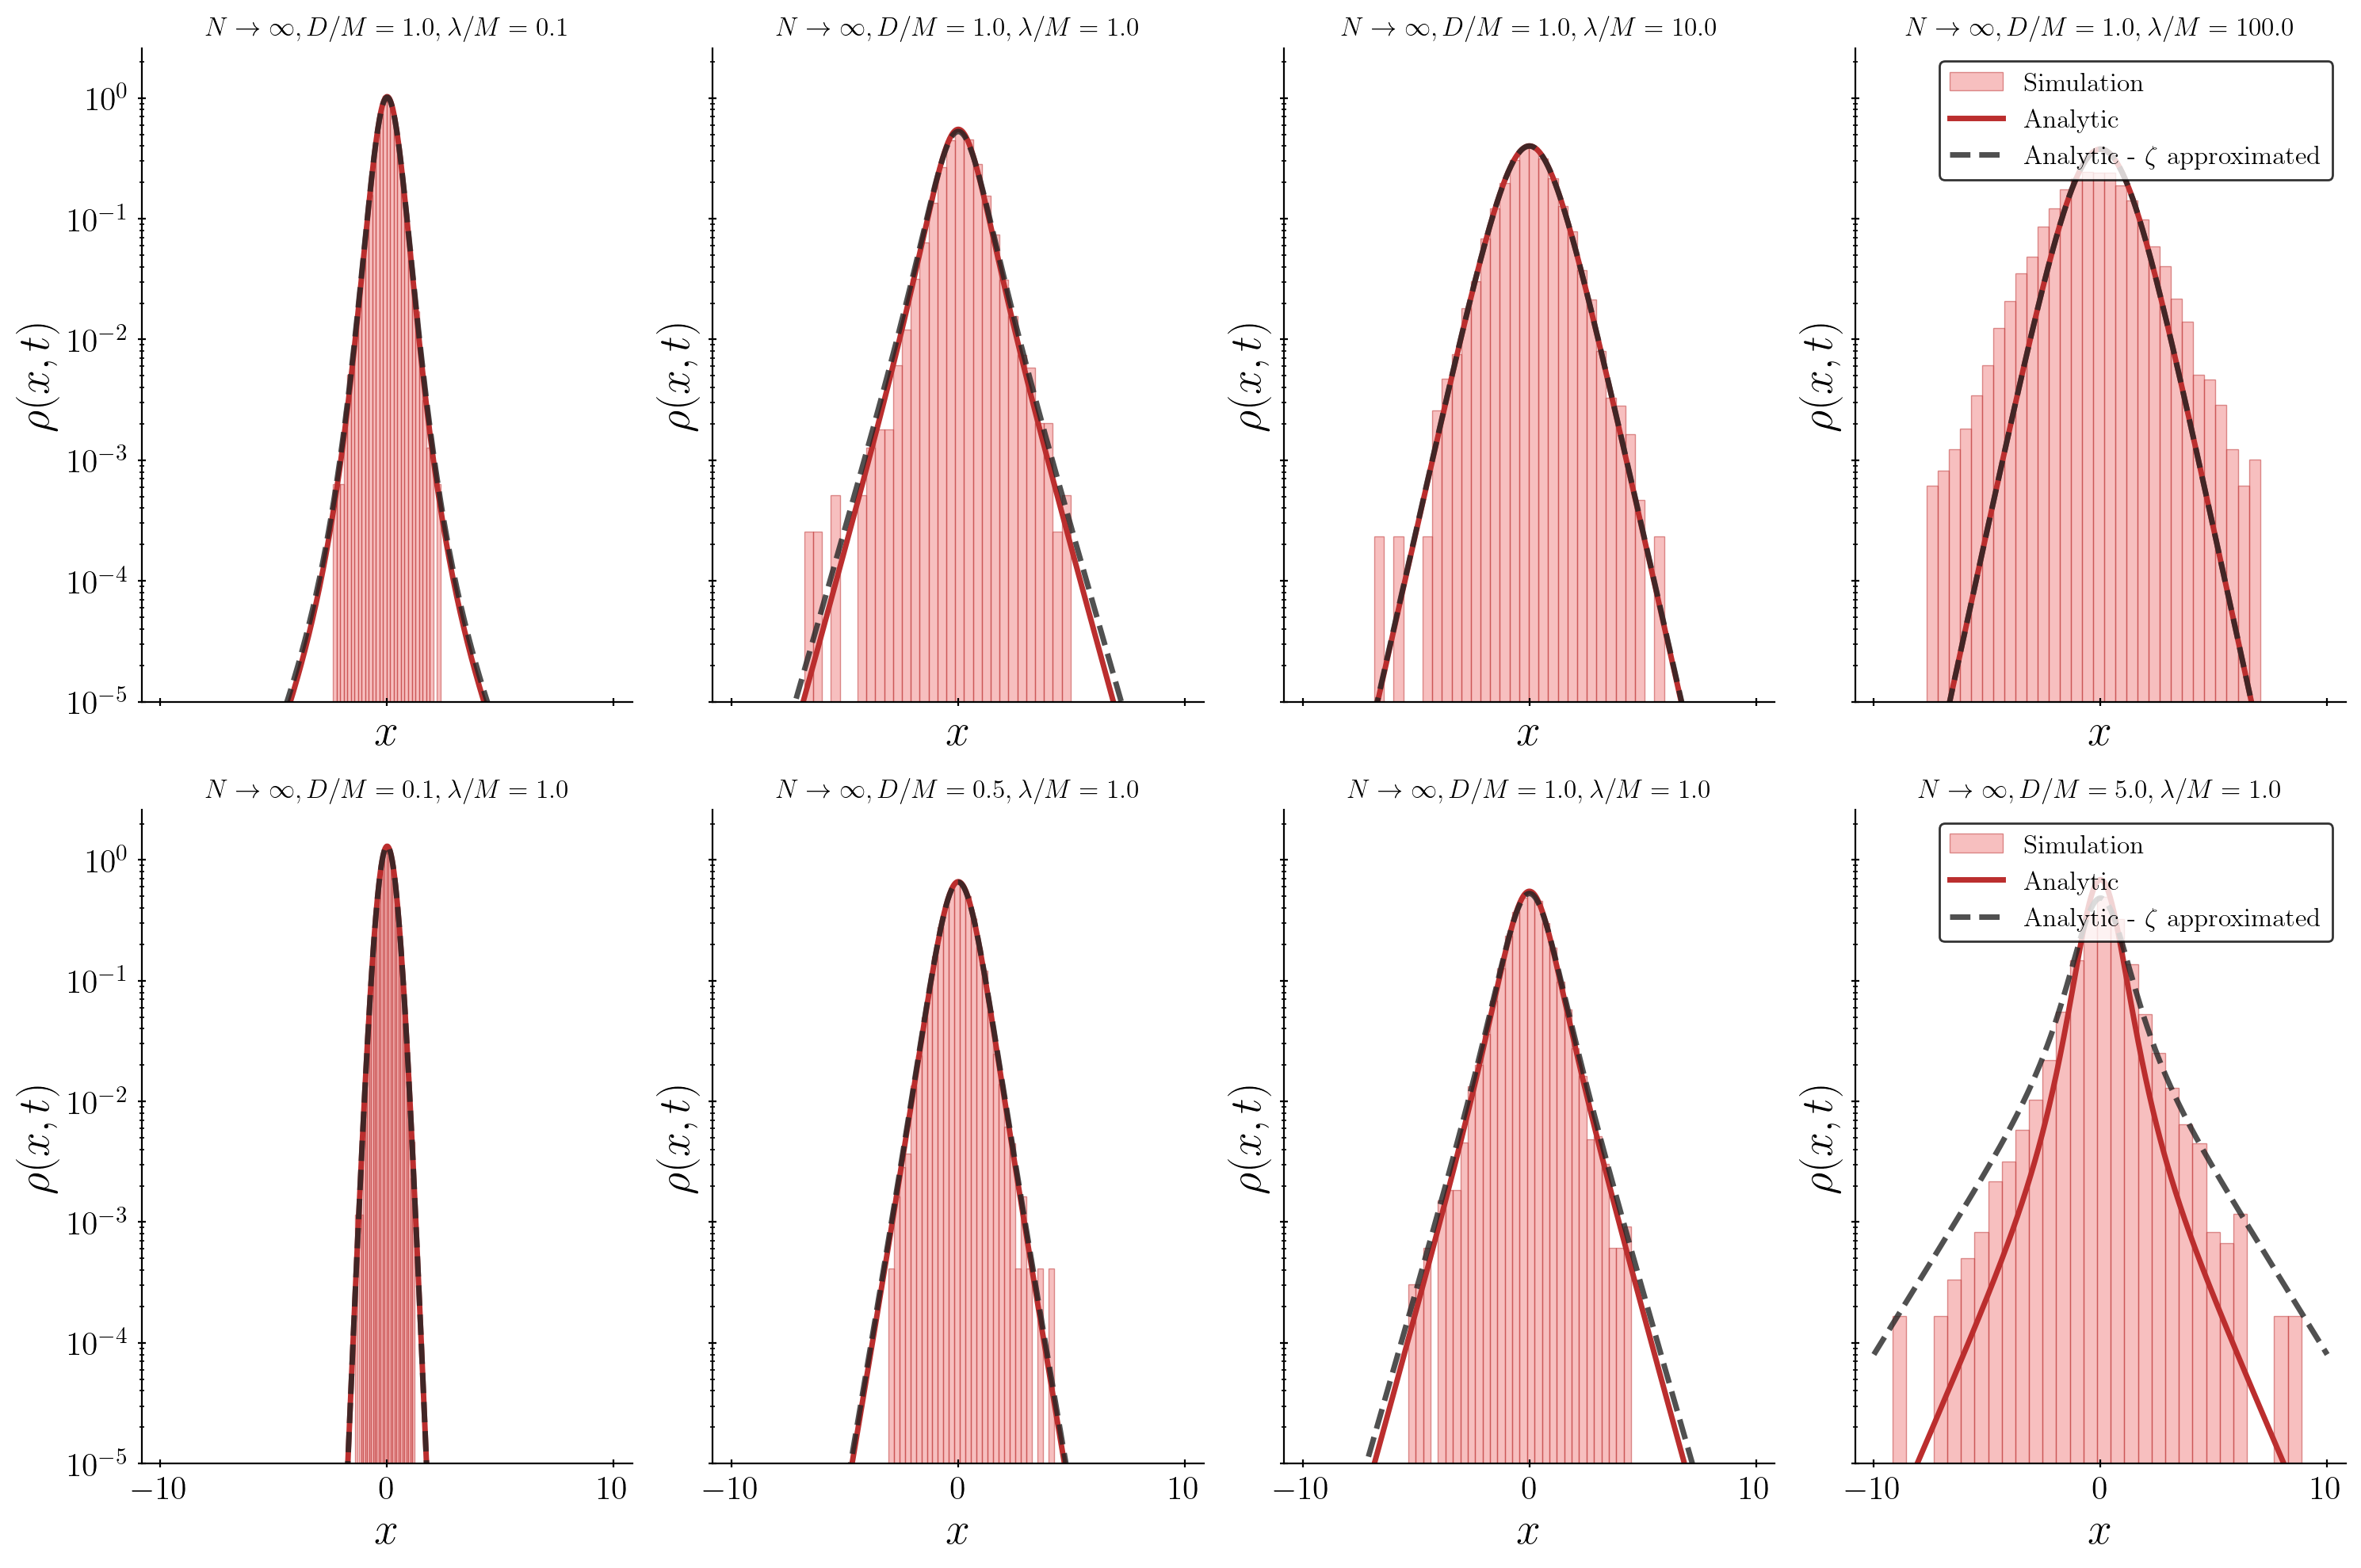

In [7]:
n_steps = int(2e4)
n_runs = int(1e4)
t_max = 500
dt = t_max/n_steps

fig, ax = plt.subplots(2, 4, figsize=(15, 10), layout='tight', sharex=True, sharey=True)

t_eval = 400
x_vals = np.linspace(-10, 10, 500)

y0 = np.full(n_runs, 0.0)
eta0 = np.full(n_runs, 0.0)

#Changing lambda
M = 1
D = 1
lambs = [0.1, 1, 10, 100]
for i, lamb in enumerate(lambs):
    
    sim_step = partial(lib.mean_field_y_coloured_noise_step, M=M, D=D, lamb=lamb)
    results_y1, results_t = lib.run_simulation(y0, t_max, n_runs, n_steps, sim_step, eta0=eta0)
    results_y2, results_t = lib.run_simulation(y0, t_max, n_runs, n_steps, sim_step, eta0=eta0)
    results_x_coloured_mf = results_y1 - results_y2
    
    ax[0, i].hist(results_x_coloured_mf[int(t_eval/dt)], bins=30, density=True, color='lightcoral', linewidth=0.5, edgecolor="#BB2E2E", alpha=0.5,  label='Simulation')
    ax[0, i].plot(x_vals, lib.mean_field_steady_state_density_x_coloured_noise(x_vals, M, D, lamb), linewidth=2.5, c="#BB2E2E", alpha=1, linestyle="-", label='Analytic')
    ax[0, i].plot(x_vals, lib.mean_field_steady_state_density_x_coloured_noise(x_vals, M, D, lamb, approximate_zeta=True), linewidth=2.5, c="#242424", alpha=0.8, linestyle="--", label=r'Analytic - $\zeta$ approximated')

    ax[0, i].set_xlim([np.min(results_x_coloured_mf), np.max(results_x_coloured_mf)])
    ax[0, i].set_xlabel("$x$", fontsize=20)
    ax[0, i].set_ylabel("$\\rho(x, t)$", fontsize=20)
    ax[0, i].set_title(fr"$N\rightarrow \infty, D/M={D/M},  \lambda/M={lamb/M}$")
    ax[0, i].set_yscale('log')

ax[0, -1].legend(edgecolor='black');    
ax[0, 0].set_ylim([1e-5, None])

#Changing D
M = 1
Ds = [0.1, 0.5, 1, 5]
lamb = 1
for i, D in enumerate(Ds):
    
    sim_step = partial(lib.mean_field_y_coloured_noise_step, M=M, D=D, lamb=lamb)
    results_y1, results_t = lib.run_simulation(y0, t_max, n_runs, n_steps, sim_step, eta0=eta0)
    results_y2, results_t = lib.run_simulation(y0, t_max, n_runs, n_steps, sim_step, eta0=eta0)
    results_x_coloured_mf = results_y1 - results_y2
    
    ax[1, i].hist(results_x_coloured_mf[int(t_eval/dt)], bins=30, density=True, color='lightcoral', linewidth=0.5, edgecolor="#BB2E2E", alpha=0.5,  label='Simulation')
    ax[1, i].plot(x_vals, lib.mean_field_steady_state_density_x_coloured_noise(x_vals, M, D, lamb), linewidth=2.5, c="#BB2E2E", alpha=1, linestyle="-", label='Analytic')
    ax[1, i].plot(x_vals, lib.mean_field_steady_state_density_x_coloured_noise(x_vals, M, D, lamb, approximate_zeta=True), linewidth=2.5, c="#242424", alpha=0.8, linestyle="--", label=r'Analytic - $\zeta$ approximated')

    ax[1, i].set_xlim([np.min(results_x_coloured_mf), np.max(results_x_coloured_mf)])
    ax[1, i].set_xlabel("$x$", fontsize=20)
    ax[1, i].set_ylabel("$\\rho(x, t)$", fontsize=20)
    ax[1, i].set_title(fr"$N\rightarrow \infty, D/M={D/M},  \lambda/M={lamb/M}$")
    ax[1, i].set_yscale('log')

ax[1, -1].legend(edgecolor='black');    
ax[1, 0].set_ylim([1e-5, None])
plt.savefig('../figures/SI_approximate_zeta_vs_exact.pdf', bbox_inches='tight', dpi=200, transparent=True);

## Numerically classify bistability

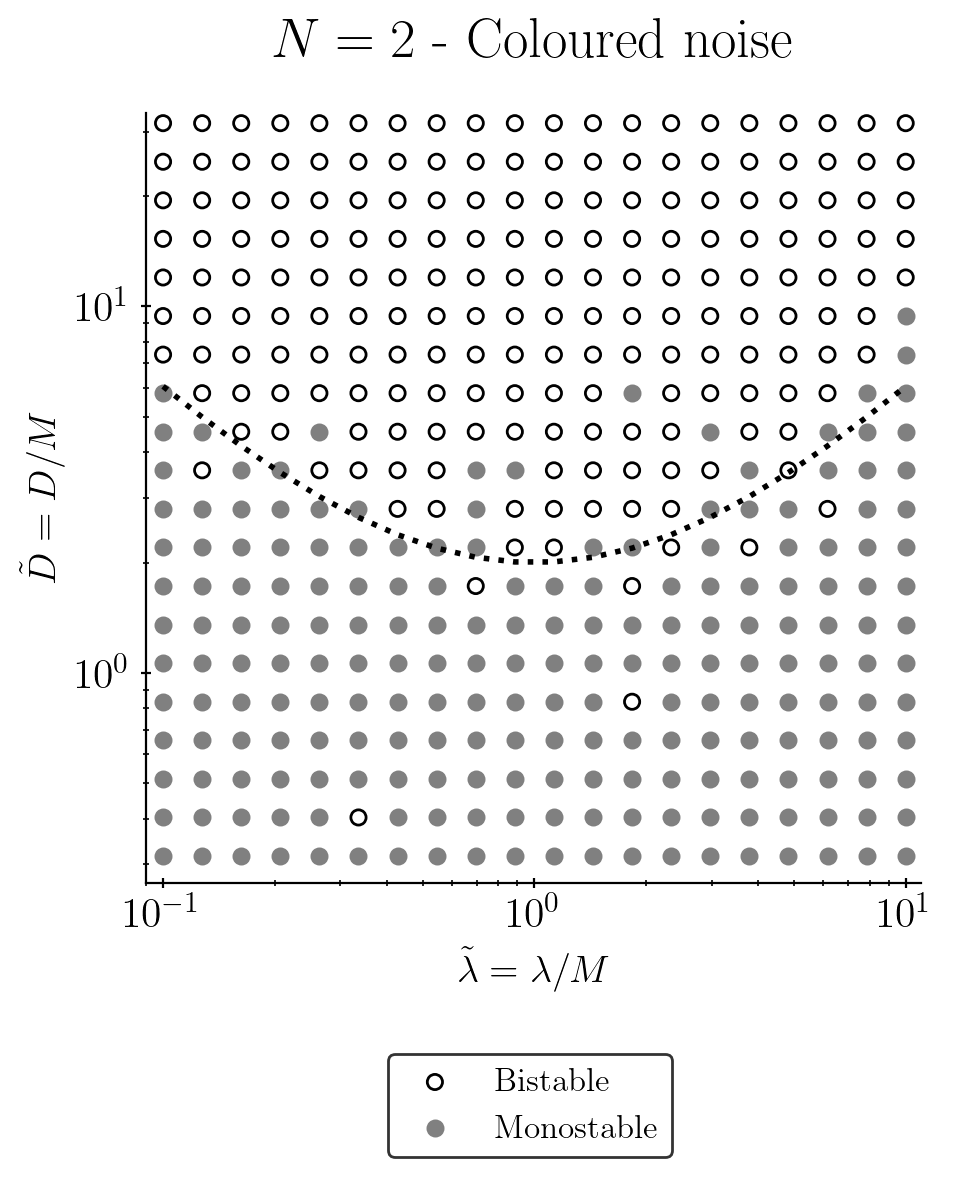

In [51]:
data = np.load("../data/numerical_results/numerical_phase_diagram_prominence_0.02.npz")
D_tildes = data["D_tildes"]
lamb_tildes = data["lamb_tildes"]
phase_diagram = data["phase_diagram"]

fig, ax = plt.subplots(figsize=(5, 5))

D_crit = (lamb_tildes  + 1)**2 / (2 * lamb_tildes)
ax.plot(lamb_tildes, D_crit, 'k:', linewidth=2)

L, D = np.meshgrid(lamb_tildes, D_tildes)

mask_1 = phase_diagram == 1
mask_0 = phase_diagram == 0


ax.scatter(L[mask_0], D[mask_0], facecolors="none", edgecolors="black", marker="o", s=30, label="Bistable")
ax.scatter(L[mask_1], D[mask_1], c="grey", marker="o", s=30, label="Monostable")

ax.set_xlabel(r'$\tilde{\lambda} = \lambda/M$')
ax.set_ylabel(r'$\tilde{D} = D/M$')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title(r"$N = 2$ - Coloured noise", fontsize=20, pad=20)

ax.set_xlim(np.min(lamb_tildes)-0.01, np.max(lamb_tildes)+1)
ax.set_ylim(np.min(D_tildes)-0.05, np.max(D_tildes)+2)
ax.legend(bbox_to_anchor=(0.7, -0.2), edgecolor='black')
plt.savefig('../figures/SI_numerical_phase_diagram.pdf', bbox_inches='tight', dpi=200, transparent=True);